# Spatial Heterogeneity Analysis

---

## Setup

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys, json, subprocess

import matplotlib.pyplot as plt

import io
import imageio

from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu


In [149]:
# ── project layout ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs/spatial'

OUTPUT_ROOT.mkdir(exist_ok=True)

# ── spatiotemporal signal propagation graph construction parameters ────────────
SIGNAL_COL    = 'ERKKTR_ratio'
SPATIAL_RADIUS = 60
FUTURE_WINDOW  = 3
JUMP_QUANTILE  = 0.9

# ── helper: path to outputs for a given run ───────────────────────────────────
def output_dir(exp, site, signal=SIGNAL_COL):
    return OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}'

def load_summary(exp, site, signal=SIGNAL_COL):
    path = output_dir(exp, site, signal) / 'summary.json'
    with open(path) as f:
        return json.load(f)

print('Project root:', PROJECT_ROOT)
print('Data file exists:', DATA_PATH.exists())

Project root: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2
Data file exists: True


## Run spatiotemporal signal propagation script on single block to demonstrate spatial classification

In [150]:
EXP_ID        = 1
SITE_ID       = 1

cmd = [
    sys.executable,
    str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
    '--data-path',           str(DATA_PATH),
    '--meta-path',           str(META_PATH),
    '--exp-id',              str(EXP_ID),
    '--site-id',             str(SITE_ID),
    '--signal-col',          SIGNAL_COL,
    '--spatial-radius',      str(SPATIAL_RADIUS),
    '--future-window-frames', str(FUTURE_WINDOW),
    '--jump-quantile',       str(JUMP_QUANTILE),
    '--output-dir',          str(OUTPUT_ROOT),
]

print('Running script …')
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Running script …

Spatiotemporal graph analysis complete.
Output directory: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2/analysis_outputs/spatial/exp_1_site_1_ERKKTR_ratio
Mutation: WT
Nodes: 356,632
Spatial edges: 2,389,504
Temporal edges: 354,834
Jump threshold on ERKKTR_ratio: 0.0365
Interpretation of "jump": a large upward change since the previous frame.
Neighbour jump now means: at least one nearby cell shows such a large upward change at the current frame.
Future self jump means: the same cell shows such a large upward change within the next 3 frames.
Future jump rate with neighbour jump now: 0.13145546310189607
Future jump rate without neighbour jump now: 0.07486715044854579
Risk difference: 0.05658831265335028 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.7558496926130764 (times more likely; 1 means no difference, >1 means more likely).



## Nodes classification as edge or central
### Set edge margin parameter
TODO algorithm description

In [151]:
EDGE_MARGIN_PERCENTILE = 5

In [152]:
nodes = pd.read_csv(output_dir(EXP_ID, SITE_ID) / 'nodes.csv.gz')
from scripts.spatial_edge_propagation_analysis import classify_frame_edges

nodes['spatial_category'] = nodes.groupby('Image_Metadata_T').apply(
    lambda g: pd.Series(classify_frame_edges(g,EDGE_MARGIN_PERCENTILE), index=g.index)
).reset_index(level=0, drop=True)

### A quick demonstration of how groups are assigned

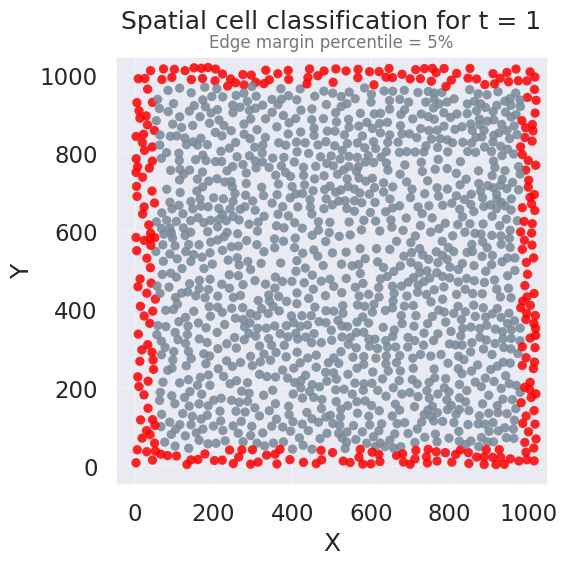

In [153]:
def spatial_classification_visualisation(snapshot):
    """Generates a scatter plot for a single time frame showing edge vs central cells."""
    # Extract the current time point directly from the snapshot data
    t = snapshot["Image_Metadata_T"].iloc[0]

    # Map colors based on the dynamic spatial category
    colors = np.where(
        snapshot["spatial_category"] == "edge", "red", "lightslategray"
    )

    # Initialize the plot with fixed square dimensions
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        snapshot["objNuclei_Location_Center_X"],
        snapshot["objNuclei_Location_Center_Y"],
        c=colors,
        s=45,
        alpha=0.85,
        edgecolor="none",
    )

    # Set rigid limits for X and Y axes to prevent jumping during animation
    ax.set_xlim(-50, 1050)
    ax.set_ylim(-50, 1050)

    # Main title with padding to make room for the subtitle
    ax.set_title(f"Spatial cell classification for t = {t}", pad=20)

    # Subtitle indicating the percentile used
    ax.text(0.5, 1.01, f"Edge margin percentile = {EDGE_MARGIN_PERCENTILE}%", transform=ax.transAxes,
        fontsize=12, color="#777777", ha="center", va="bottom",
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    return fig

snapshot_time = 1
snapshot = nodes[nodes["Image_Metadata_T"] == snapshot_time]
single_fig = spatial_classification_visualisation(snapshot)

#### Generate a gif for all t

In [161]:
# Sort time points to ensure chronological order in the GIF
time_points = sorted(nodes["Image_Metadata_T"].unique())
frames_images = []

print("Generating frames...")
for t in time_points:
    # Filter data for the current frame
    snapshot = nodes[nodes["Image_Metadata_T"] == t]

    if snapshot.empty:
        continue

    # 1. Call the standalone visualization function to create the figure
    fig = spatial_classification_visualisation(snapshot)

    # 2. Save the current figure directly to a memory buffer
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    buf.seek(0)

    # 3. Read the image from buffer and append to the frames list
    frames_images.append(imageio.v2.imread(buf))

    # 4. Close the plot to release memory immediately
    plt.close(fig)

# Save all gathered frames into an animated GIF
output_gif_path = OUTPUT_ROOT / "cell_propagation_boundaries.gif"
imageio.mimsave(output_gif_path, frames_images, fps=20, loop=0)

print(f"Animated GIF successfully saved to: {output_gif_path}")

Generating frames...
Animated GIF successfully saved to: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2/analysis_outputs/spatial/cell_propagation_boundaries.gif


### Number of cells classified to each category

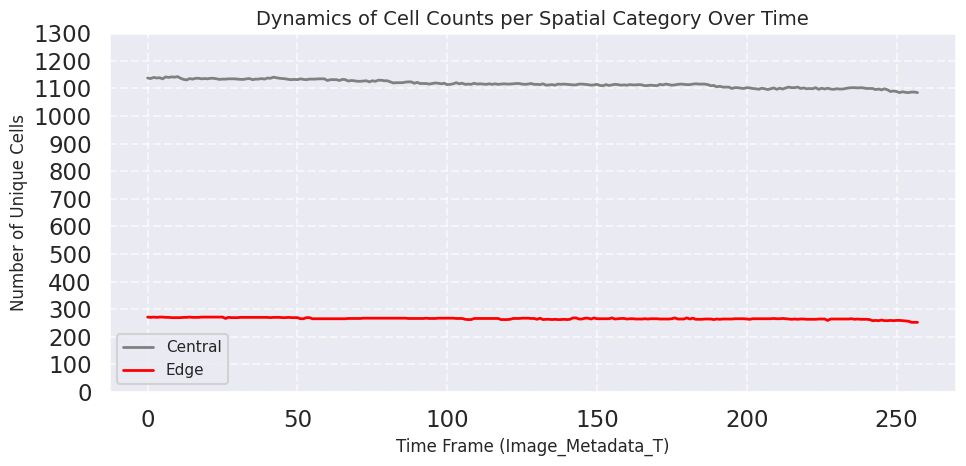

In [160]:
# We count unique track_ids at each time point (frame) for each spatial category
counts_per_frame = (
    nodes.groupby(["Image_Metadata_T", "spatial_category"])["track_id"]
    .nunique()
    .unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(10, 5))

# Plot central cells (gray)
ax.plot(
    counts_per_frame.index,
    counts_per_frame["central"],
    color="gray",
    linestyle="-",
    linewidth=2,
    label="Central",
)

# Plot edge cells (red)
ax.plot(
    counts_per_frame.index,
    counts_per_frame["edge"],
    color="red",
    linestyle="-",
    linewidth=2,
    label="Edge",
)

# Chart styling
ax.set_title("Dynamics of Cell Counts per Spatial Category Over Time", fontsize=14)
ax.set_xlabel("Time Frame (Image_Metadata_T)", fontsize=12)
ax.set_ylabel("Number of Unique Cells", fontsize=12)
ax.set_yticks(ticks = range(0, max(counts_per_frame["central"]) + 200,100))

ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="best", fontsize=11)

plt.savefig(OUTPUT_ROOT / "n_cells_by_category_example_plot.png")
plt.tight_layout()
plt.show()

## Multiple experiment analysis
### Listing all existing (Exp_id, Image_Metadata_Site) blocks present in data

In [162]:
# importing already implemented function for such task
from scripts.compare_spatiotemporal_behavior import find_available_blocks
CHUNKSIZE = 1_000_000

print("Scanning the large dataset to find all available blocks...")

available_blocks_df = find_available_blocks(DATA_PATH, chunksize=CHUNKSIZE)

print(f"\nSuccessfully found {len(available_blocks_df)} available blocks across the dataset:")

all_blocks_tuples = list(available_blocks_df.itertuples(index=False, name=None))
print(all_blocks_tuples)

Scanning the large dataset to find all available blocks...

Successfully found 120 available blocks across the dataset
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (2, 1), (2, 2), (2, 3), (2, 4), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17), (2, 18), (2, 19), (2, 20), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (3, 17), (3, 18), (3, 19), (3, 20), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (4, 12), (4, 13), (4, 14), (4, 15), (4, 16), (4, 17), (4, 18), (4, 19), (4, 20), (5, 1), (5, 2), (5, 3), (5, 4), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (5, 14), (5, 15), (5, 16), (5, 17), (5, 18), (5, 20), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6

In [144]:
EDGE_MARGIN_PERCENTILE = 5.0

# Choose which experiments to batch analyze (e.g., Experiments 1, 2, and 3)
CHOSEN_EXP_IDS = [1, 2, 3]

# Build the execution command package
cmd = [
    sys.executable,
    str(SCRIPTS_DIR / "spatial_edge_propagation_analysis.py"),
    "--data-path",
    str(DATA_PATH),
    "--meta-path",
    str(META_PATH),
    "--signal-col",
    SIGNAL_COL,
    "--spatial-radius",
    str(SPATIAL_RADIUS),
    "--future-window-frames",
    str(FUTURE_WINDOW),
    "--jump-quantile",
    str(JUMP_QUANTILE),
    "--edge-margin-percentile",
    str(EDGE_MARGIN_PERCENTILE),
    "--output-dir",
    str(OUTPUT_ROOT),
    "--chosen-exp-ids",
] + [str(eid) for eid in CHOSEN_EXP_IDS]

print("Running batch spatial boundary analysis script...")
result = subprocess.run(cmd, capture_output=True, text=True)

# Output results and telemetry logs directly inside the notebook cell
print(result.stdout)
if result.returncode != 0:
    print("ERROR OCCURRED (STDERR):", result.stderr)

Running batch spatial boundary analysis script...
LOADING EXPERIMENT 1 INTO MEMORY
 -> [Exp 1, Site 1] Building graph & boundaries...
 -> [Exp 1, Site 2] Building graph & boundaries...
 -> [Exp 1, Site 3] Building graph & boundaries...
 -> [Exp 1, Site 4] Building graph & boundaries...
 -> [Exp 1, Site 5] Building graph & boundaries...
 -> [Exp 1, Site 6] Building graph & boundaries...
 -> [Exp 1, Site 7] Building graph & boundaries...
 -> [Exp 1, Site 8] Building graph & boundaries...
 -> [Exp 1, Site 9] Building graph & boundaries...
 -> [Exp 1, Site 10] Building graph & boundaries...
 -> [Exp 1, Site 11] Building graph & boundaries...
 -> [Exp 1, Site 12] Building graph & boundaries...
 -> [Exp 1, Site 13] Building graph & boundaries...
 -> [Exp 1, Site 14] Building graph & boundaries...
 -> [Exp 1, Site 15] Building graph & boundaries...
 -> [Exp 1, Site 16] Building graph & boundaries...
 -> [Exp 1, Site 17] Building graph & boundaries...
 -> [Exp 1, Site 18] Building graph & boun

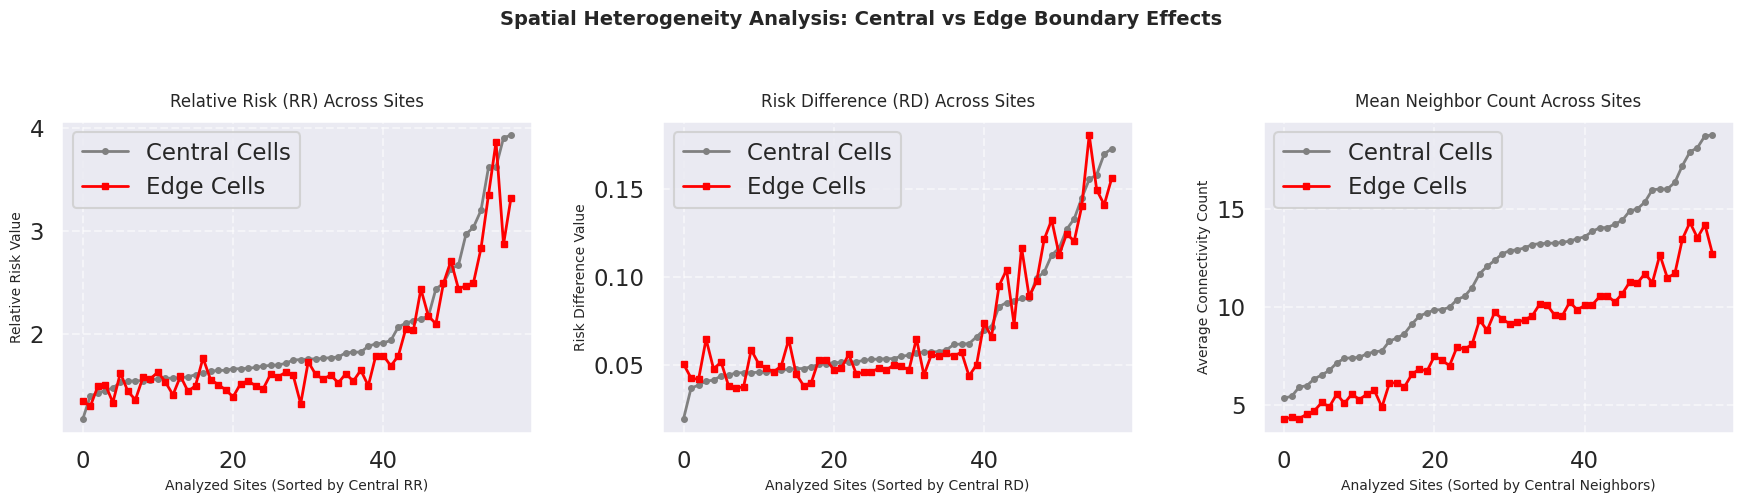

In [159]:
summary_file_path = OUTPUT_ROOT / 'spatial_edge_comparison_summary.csv'
summary_df = pd.read_csv(summary_file_path)

# Drop any potential NaN values to ensure continuous lines on the plots
plot_df = summary_df.dropna(
    subset=[
        "rr_central",
        "rr_edge",
        "rd_central",
        "rd_edge",
        "mean_neighbors_central",
        "mean_neighbors_edge",
    ]
).copy()

# Create a dummy index for the X-axis representing sorted sequential site counts
plot_df = plot_df.reset_index(drop=True)
x_axis = range(len(plot_df))

fig, ax = plt.subplots(figsize=(18, 5), nrows=1, ncols=3)

# --- Subplot 0: Relative Risk (RR) Comparison ---
# Sort by central RR to make the visualization clean and easy to interpret
df_rr = plot_df.sort_values(by="rr_central").reset_index(drop=True)

ax[0].plot(
    x_axis,
    df_rr["rr_central"],
    color="gray",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Central Cells",
)
ax[0].plot(
    x_axis,
    df_rr["rr_edge"],
    color="red",
    linewidth=2,
    marker="s",
    markersize=4,
    label="Edge Cells",
)

ax[0].set_title("Relative Risk (RR) Across Sites", fontsize=12, pad=10)
ax[0].set_xlabel("Analyzed Sites (Sorted by Central RR)", fontsize=10)
ax[0].set_ylabel("Relative Risk Value", fontsize=10)
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].legend(loc="best")

# --- Subplot 1: Risk Difference (RD) Comparison ---
# Sort by central RD for visual alignment
df_rd = plot_df.sort_values(by="rd_central").reset_index(drop=True)

ax[1].plot(
    x_axis,
    df_rd["rd_central"],
    color="gray",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Central Cells",
)
ax[1].plot(
    x_axis,
    df_rd["rd_edge"],
    color="red",
    linewidth=2,
    marker="s",
    markersize=4,
    label="Edge Cells",
)

ax[1].set_title("Risk Difference (RD) Across Sites", fontsize=12, pad=10)
ax[1].set_xlabel("Analyzed Sites (Sorted by Central RD)", fontsize=10)
ax[1].set_ylabel("Risk Difference Value", fontsize=10)
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend(loc="best")

# --- Subplot 2: Mean Neighbors Count Comparison ---
# Sort by central neighbor count to demonstrate the geometric boundary effect
df_neigh = plot_df.sort_values(by="mean_neighbors_central").reset_index(drop=True)

ax[2].plot(
    x_axis,
    df_neigh["mean_neighbors_central"],
    color="gray",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Central Cells",
)
ax[2].plot(
    x_axis,
    df_neigh["mean_neighbors_edge"],
    color="red",
    linewidth=2,
    marker="s",
    markersize=4,
    label="Edge Cells",
)

ax[2].set_title("Mean Neighbor Count Across Sites", fontsize=12, pad=10)
ax[2].set_xlabel("Analyzed Sites (Sorted by Central Neighbors)", fontsize=10)
ax[2].set_ylabel("Average Connectivity Count", fontsize=10)
ax[2].grid(True, linestyle="--", alpha=0.5)
ax[2].legend(loc="best")

plt.suptitle(
    "Spatial Heterogeneity Analysis: Central vs Edge Boundary Effects",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.savefig(OUTPUT_ROOT / "spatial_heterogeneity_analysis_plots.png")
plt.tight_layout()

plt.show()


In [147]:
print("=== Spatial Boundary Metrics Table (First 10 Sites) ===")
display(summary_df.head(10))

# 2. Data Cleaning: Drop rows with missing RR data to satisfy test criteria
clean_df = summary_df.dropna(subset=["rr_edge", "rr_central"])

print(
    f"\nTotal sites available for paired analysis: {len(clean_df)} (out of {len(summary_df)})"
)

# 3. Apply Wilcoxon Signed-Rank Test (Paired higher-level test)
if len(clean_df) >= 5:
    stat, p_value = wilcoxon(
        clean_df["rr_edge"], clean_df["rr_central"], alternative="two-sided"
    )

    print("\n" + "=" * 50)
    print("HIGHER-LEVEL STATISTICAL INFERENCE (Wilcoxon Test)")
    print("=" * 50)
    print(f"Null Hypothesis (H0): RR_edge and RR_central share the same distribution.")
    print(f"Alternative Hypothesis (H1): RR significantly shifts between boundary and center.")
    print(f"Wilcoxon statistic: {stat}")
    print(f"Calculated p-value: {p_value:.4e}")

    # Statistical significance interpretation block
    alpha = 0.05
    if p_value < alpha:
        print(
            f"\nConclusion: Reject H0 (p < {alpha}). There is a statistically significant "
            "difference in signal propagation efficiency (RR) between Edge and Central cells!"
        )
        # Find the direction of the effect
        mean_edge = clean_df["rr_edge"].mean()
        mean_central = clean_df["rr_central"].mean()
        print(
            f"Mean RR Edge: {mean_edge:.3f} | Mean RR Central: {mean_central:.3f}"
        )
        if mean_edge < mean_central:
            print(
                " -> Spatial boundary constraints reduce the likelihood of neighbour-driven propagation."
            )
        else:
            print(
                " -> Curiously, edge cells exhibit higher neighbour coordination risks despite boundary effects."
            )
    else:
        print(
            f"\nConclusion: Fail to reject H0 (p >= {alpha}). No significant difference in propagation "
            "behavior (RR) was detected between Edge and Central zones across the population."
        )
else:
    print(
        "\n[Warning] Not enough valid paired sites without NaNs to run a meaningful Wilcoxon test."
    )


=== Spatial Boundary Metrics Table (First 10 Sites) ===


,Exp_ID,Site_ID,rr_edge,rr_central,rd_edge,rd_central,mean_neighbors_edge,mean_neighbors_central,mw_p_value
0,1,1,1.610716,1.814384,0.055072,0.057725,10.595555,14.067014,0.0
1,1,2,1.492939,1.877905,0.044463,0.057380,9.868986,13.497436,0.0
2,1,3,1.463024,1.685238,0.038419,0.048151,10.552315,14.055215,0.0
3,1,4,1.786482,1.901620,0.055152,0.061821,11.228979,15.017392,0.0
4,1,5,1.505537,1.642899,0.065118,0.057106,14.330234,17.925165,0.0
5,1,6,1.785359,2.066322,0.073054,0.086164,12.730841,18.788018,0.0
6,1,7,2.097320,2.437509,0.097524,0.099521,11.716586,15.367858,0.0
7,1,8,2.049827,2.102795,0.095089,0.083194,13.485992,17.232156,0.0
8,1,9,1.512782,1.659144,0.047115,0.055646,9.222874,12.933080,0.0
9,1,10,1.537858,1.819874,0.050270,0.066071,10.126460,13.874194,0.0



Total sites available for paired analysis: 58 (out of 58)

HIGHER-LEVEL STATISTICAL INFERENCE (Wilcoxon Test)
Null Hypothesis (H0): RR_edge and RR_central share the same distribution.
Alternative Hypothesis (H1): RR significantly shifts between boundary and center.
Wilcoxon statistic: 230.0
Calculated p-value: 1.2800e-06

Conclusion: Reject H0 (p < 0.05). There is a statistically significant difference in signal propagation efficiency (RR) between Edge and Central cells!
Mean RR Edge: 1.827 | Mean RR Central: 1.975
 -> Spatial boundary constraints reduce the likelihood of neighbour-driven propagation.
